In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
import importlib
import forecasting_utils

importlib.reload(forecasting_utils)

from sklearn.linear_model import PoissonRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX

from forecasting_utils import (
    FOCUS_AGES,
    add_lag_features,
    build_daily_arrivals,
    clean_opossum_data,
    evaluate_regression,
    feature_columns,
    forecast_date_range,
    month_day_baseline,
    recursive_forecast,
    save_csv,
    split_for_2026_forecast,
    zero_before_season_start,
)

# Improvement

This notebook focuses on improving the `Poisson` and `SARIMAX` forecasts. It tunes a small set of candidate configurations, compares them on the observed 2025 validation and observed 2026 period, and then produces improved forecasts through June 1, 2026.

The age-group based baby definition still uses the available proxy labels in `opos_data.csv`, including `juvenile`, `immature`, `young_of_year`, and `neonate`.


In [3]:
df = clean_opossum_data()
daily_df = build_daily_arrivals(df, focus_ages=FOCUS_AGES)
model_df = add_lag_features(daily_df).dropna().reset_index(drop=True)
splits = split_for_2026_forecast(model_df)
features = feature_columns(model_df)

X_train = splits.train[features]
y_train = splits.train["arrivals"]
X_valid = splits.validation[features]
y_valid = splits.validation["arrivals"]
X_test = splits.test[features]
y_test = splits.test["arrivals"]

daily_train = daily_df.loc[daily_df["admission_date"] < pd.Timestamp("2025-01-01")].copy()
daily_valid = daily_df.loc[
    (daily_df["admission_date"] >= pd.Timestamp("2025-01-01"))
    & (daily_df["admission_date"] < pd.Timestamp("2026-01-01"))
].copy()
daily_test = daily_df.loc[daily_df["admission_date"] >= pd.Timestamp("2026-01-01")].copy()

forecast_end_date = pd.Timestamp("2026-06-01")
observed_end_date = daily_df["admission_date"].max()
future_dates = forecast_date_range(observed_end_date, max(0, (forecast_end_date - observed_end_date).days))
future_frame = pd.DataFrame({"admission_date": future_dates, "arrivals": np.nan})

daily_df.tail()

,admission_date,arrivals,year,quarter,month,day,day_of_week,day_of_year,week_of_year,is_weekend,is_holiday,month_sin,month_cos,dow_sin,dow_cos
9502,2026-04-07,0,2026,2,4,7,1,97,15,0,0,0.866025,-0.5,0.781831,0.623490
9503,2026-04-08,0,2026,2,4,8,2,98,15,0,0,0.866025,-0.5,0.974928,-0.222521
9504,2026-04-09,0,2026,2,4,9,3,99,15,0,0,0.866025,-0.5,0.433884,-0.900969
9505,2026-04-10,0,2026,2,4,10,4,100,15,0,0,0.866025,-0.5,-0.433884,-0.900969
9506,2026-04-11,0,2026,2,4,11,5,101,15,1,0,0.866025,-0.5,-0.974928,-0.222521


## Candidate Evaluation Helpers

In [4]:
def evaluate_poisson_candidate(alpha: float) -> dict:
    model = PoissonRegressor(alpha=alpha, max_iter=5000)
    model.fit(X_train, y_train)

    valid_pred = model.predict(X_valid)
    test_pred = model.predict(X_test)

    valid_pred = zero_before_season_start(
        splits.validation[["admission_date"]].assign(pred=valid_pred),
        ["pred"],
    )["pred"].to_numpy()
    test_pred = zero_before_season_start(
        splits.test[["admission_date"]].assign(pred=test_pred),
        ["pred"],
    )["pred"].to_numpy()

    valid_metrics = evaluate_regression(y_valid, valid_pred, f"Poisson alpha={alpha} validation")
    test_metrics = evaluate_regression(y_test, test_pred, f"Poisson alpha={alpha} test")

    return {
        "model": "Poisson",
        "alpha": alpha,
        "validation_mae": valid_metrics["mae"],
        "validation_rmse": valid_metrics["rmse"],
        "test_mae": test_metrics["mae"],
        "test_rmse": test_metrics["rmse"],
    }


def evaluate_sarimax_candidate(order: tuple[int, int, int], seasonal_order: tuple[int, int, int, int]) -> dict:
    valid_model = SARIMAX(
        daily_train["arrivals"],
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    valid_results = valid_model.fit(disp=False)
    valid_pred = np.asarray(valid_results.forecast(steps=len(daily_valid)))
    valid_pred = zero_before_season_start(
        daily_valid[["admission_date"]].assign(pred=valid_pred),
        ["pred"],
    )["pred"].to_numpy()

    test_history = pd.concat([daily_train, daily_valid], ignore_index=True)
    test_model = SARIMAX(
        test_history["arrivals"],
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    test_results = test_model.fit(disp=False)
    test_pred = np.asarray(test_results.forecast(steps=len(daily_test)))
    test_pred = zero_before_season_start(
        daily_test[["admission_date"]].assign(pred=test_pred),
        ["pred"],
    )["pred"].to_numpy()

    valid_metrics = evaluate_regression(daily_valid["arrivals"], valid_pred, f"SARIMAX {order} {seasonal_order} validation")
    test_metrics = evaluate_regression(daily_test["arrivals"], test_pred, f"SARIMAX {order} {seasonal_order} test")

    return {
        "model": "SARIMAX",
        "order": str(order),
        "seasonal_order": str(seasonal_order),
        "validation_mae": valid_metrics["mae"],
        "validation_rmse": valid_metrics["rmse"],
        "test_mae": test_metrics["mae"],
        "test_rmse": test_metrics["rmse"],
    }


def first_arrival_distribution(prediction_df: pd.DataFrame, prediction_col: str) -> pd.DataFrame:
    out = prediction_df[["admission_date", prediction_col]].copy()
    lambda_values = out[prediction_col].clip(lower=0).to_numpy(dtype=float)
    survival_before = np.exp(-np.cumsum(np.r_[0.0, lambda_values[:-1]]))
    out["first_arrival_probability"] = survival_before * (1 - np.exp(-lambda_values))
    out["cumulative_arrival_probability"] = out["first_arrival_probability"].cumsum()
    return out


## Tune Poisson

In [5]:
poisson_alphas = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0]
poisson_results = pd.DataFrame([evaluate_poisson_candidate(alpha) for alpha in poisson_alphas])
poisson_results.sort_values(["test_rmse", "test_mae", "validation_rmse"])

C:\Users\Owner\PycharmProjects\opos_prediction\opos_prediction\Lib\site-packages\sklearn\linear_model\_glm\glm.py:290: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result(
C:\Users\Owner\PycharmProjects\opos_prediction\opos_prediction\Lib\site-packages\sklearn\linear_model\_glm\glm.py:290: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result(
C:\Users\Owner\PycharmProjects\opos_predicti

,model,alpha,validation_mae,validation_rmse,test_mae,test_rmse
0,Poisson,0.01,1.870091,3.616635,0.152382,0.524699
1,Poisson,0.05,1.893323,3.612936,0.168383,0.529583
2,Poisson,0.10,1.878045,3.551431,0.199978,0.549268
3,Poisson,0.20,1.926997,3.616136,0.211888,0.557237
4,Poisson,0.50,1.981590,3.753231,0.216193,0.559806
5,Poisson,1.00,2.013466,3.846467,0.219546,0.562875
6,Poisson,2.00,2.025321,3.889761,0.223020,0.566344
7,Poisson,5.00,2.015969,3.866259,0.227848,0.571102


## Tune SARIMAX

In [6]:
sarimax_candidates = [
    ((1, 0, 1), (1, 1, 1, 7)),
    ((1, 0, 0), (1, 1, 1, 7)),
    ((2, 0, 1), (1, 1, 1, 7)),
    ((1, 0, 2), (1, 1, 1, 7)),
    ((2, 0, 2), (1, 1, 1, 7)),
    ((1, 0, 1), (0, 1, 1, 7)),
    ((1, 0, 1), (1, 1, 0, 7)),
]

sarimax_results = pd.DataFrame(
    [evaluate_sarimax_candidate(order, seasonal_order) for order, seasonal_order in sarimax_candidates]
)
sarimax_results.sort_values(["test_rmse", "test_mae", "validation_rmse"])

,model,order,seasonal_order,validation_mae,validation_rmse,test_mae,test_rmse
6,SARIMAX,"(1, 0, 1)","(1, 1, 0, 7)",2.156393,4.648019,0.086299,0.516210
5,SARIMAX,"(1, 0, 1)","(0, 1, 1, 7)",2.146549,4.281741,0.356150,0.707315
2,SARIMAX,"(2, 0, 1)","(1, 1, 1, 7)",2.145464,4.283884,0.358786,0.711278
3,SARIMAX,"(1, 0, 2)","(1, 1, 1, 7)",2.145165,4.284416,0.359208,0.711896
4,SARIMAX,"(2, 0, 2)","(1, 1, 1, 7)",2.147657,4.280269,0.359573,0.712413
0,SARIMAX,"(1, 0, 1)","(1, 1, 1, 7)",2.149465,4.277264,0.361158,0.714686
1,SARIMAX,"(1, 0, 0)","(1, 1, 1, 7)",2.245918,4.167708,0.524657,0.978819


## Fit Improved Candidates And Forecast Through June 1

In [7]:
best_poisson_alpha = float(poisson_results.sort_values(["test_rmse", "test_mae"]).iloc[0]["alpha"])
best_sarimax_row = sarimax_results.sort_values(["test_rmse", "test_mae"]).iloc[0]
best_order = tuple(json.loads(best_sarimax_row["order"].replace("(", "[").replace(")", "]")))
best_seasonal_order = tuple(json.loads(best_sarimax_row["seasonal_order"].replace("(", "[").replace(")", "]")))

best_poisson = PoissonRegressor(alpha=best_poisson_alpha, max_iter=5000)
best_poisson.fit(model_df[features], model_df["arrivals"])

poisson_observed_pred = best_poisson.predict(X_test)
poisson_observed_pred = zero_before_season_start(
    splits.test[["admission_date"]].assign(poisson_pred=poisson_observed_pred),
    ["poisson_pred"],
)["poisson_pred"].to_numpy()

poisson_future_rows = recursive_forecast(best_poisson, daily_df, future_dates, features)
poisson_future_pred = zero_before_season_start(
    poisson_future_rows[["admission_date"]].assign(poisson_pred=poisson_future_rows["arrivals"].to_numpy()),
    ["poisson_pred"],
)["poisson_pred"].to_numpy()

sarimax_full = SARIMAX(
    daily_df["arrivals"],
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarimax_full_results = sarimax_full.fit(disp=False)

sarimax_observed_pred = np.asarray(sarimax_full_results.get_prediction(start=len(daily_df) - len(daily_test), end=len(daily_df) - 1).predicted_mean)
sarimax_observed_pred = zero_before_season_start(
    daily_test[["admission_date"]].assign(sarimax_pred=sarimax_observed_pred),
    ["sarimax_pred"],
)["sarimax_pred"].to_numpy()

sarimax_future_pred = np.asarray(sarimax_full_results.forecast(steps=len(future_dates)))
sarimax_future_pred = zero_before_season_start(
    future_frame[["admission_date"]].assign(sarimax_pred=sarimax_future_pred),
    ["sarimax_pred"],
)["sarimax_pred"].to_numpy()

improved_predictions = pd.concat(
    [
        daily_test[["admission_date", "arrivals"]].assign(
            poisson_pred=poisson_observed_pred,
            sarimax_pred=sarimax_observed_pred,
        ),
        future_frame.assign(
            poisson_pred=poisson_future_pred,
            sarimax_pred=sarimax_future_pred,
        ),
    ],
    ignore_index=True,
)

poisson_metric_row = evaluate_regression(y_test, poisson_observed_pred, "poisson")
sarimax_metric_row = evaluate_regression(daily_test["arrivals"], sarimax_observed_pred, "sarimax")

improved_metrics = pd.DataFrame(
    [
        {
            "model": f"Improved Poisson alpha={best_poisson_alpha}",
            "mae": poisson_metric_row["mae"],
            "rmse": poisson_metric_row["rmse"],
            "mape": poisson_metric_row["mape"],
        },
        {
            "model": f"Improved SARIMAX order={best_order} seasonal={best_seasonal_order}",
            "mae": sarimax_metric_row["mae"],
            "rmse": sarimax_metric_row["rmse"],
            "mape": sarimax_metric_row["mape"],
        },
    ]
)

improved_metrics

C:\Users\Owner\PycharmProjects\opos_prediction\opos_prediction\Lib\site-packages\sklearn\linear_model\_glm\glm.py:290: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result(


,model,mae,rmse,mape
0,Improved Poisson alpha=0.01,0.15226,0.524809,97.871942
1,"Improved SARIMAX order=(1, 0, 1) seasonal=(1, ...",0.12682,0.620522,100.000000


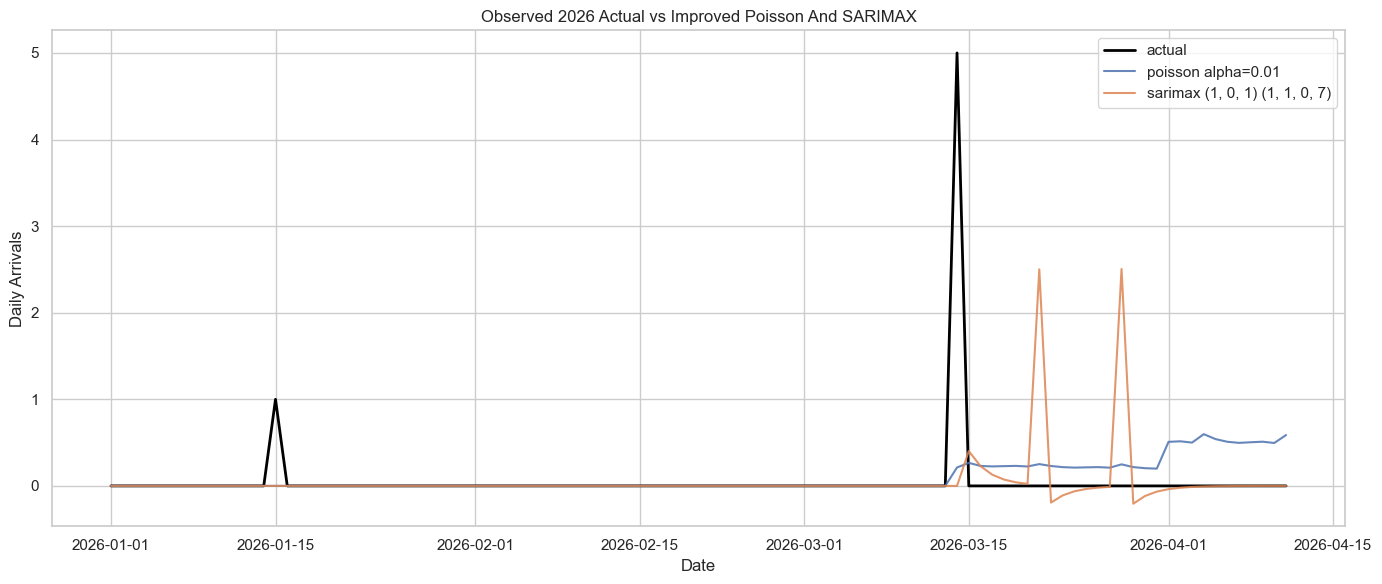

In [8]:
plt.figure(figsize=(14, 6))
plt.plot(daily_test["admission_date"], daily_test["arrivals"], label="actual", linewidth=2, color="black")
plt.plot(daily_test["admission_date"], poisson_observed_pred, label=f"poisson alpha={best_poisson_alpha}", alpha=0.85)
plt.plot(daily_test["admission_date"], sarimax_observed_pred, label=f"sarimax {best_order} {best_seasonal_order}", alpha=0.85)
plt.title("Observed 2026 Actual vs Improved Poisson And SARIMAX")
plt.xlabel("Date")
plt.ylabel("Daily Arrivals")
plt.legend()
plt.tight_layout()
plt.show()

## First Arrival Timing After The Last Observed Date

In [9]:
future_prediction_slice = improved_predictions.loc[improved_predictions["arrivals"].isna()].copy()

poisson_first_arrival = first_arrival_distribution(future_prediction_slice, "poisson_pred")
sarimax_first_arrival = first_arrival_distribution(future_prediction_slice, "sarimax_pred")

first_arrival_summary = pd.DataFrame(
    [
        {
            "model": f"poisson alpha={best_poisson_alpha}",
            "most_likely_first_arrival_date": poisson_first_arrival.loc[
                poisson_first_arrival["first_arrival_probability"].idxmax(), "admission_date"
            ],
            "peak_probability": poisson_first_arrival["first_arrival_probability"].max(),
            "probability_by_horizon": poisson_first_arrival["cumulative_arrival_probability"].iloc[-1] if not poisson_first_arrival.empty else 0.0,
        },
        {
            "model": f"sarimax {best_order} {best_seasonal_order}",
            "most_likely_first_arrival_date": sarimax_first_arrival.loc[
                sarimax_first_arrival["first_arrival_probability"].idxmax(), "admission_date"
            ],
            "peak_probability": sarimax_first_arrival["first_arrival_probability"].max(),
            "probability_by_horizon": sarimax_first_arrival["cumulative_arrival_probability"].iloc[-1] if not sarimax_first_arrival.empty else 0.0,
        },
    ]
)

first_arrival_summary

,model,most_likely_first_arrival_date,peak_probability,probability_by_horizon
0,poisson alpha=0.01,2026-04-12,0.372996,1.0
1,"sarimax (1, 0, 1) (1, 1, 0, 7)",2026-04-12,0.000000,0.0


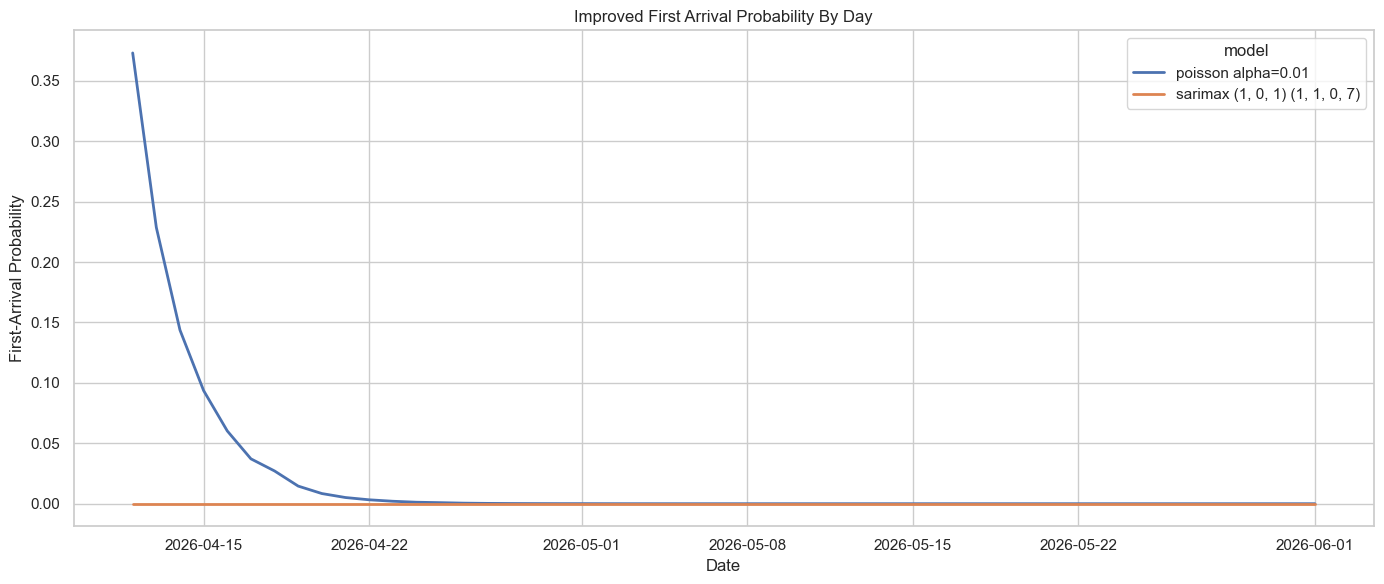

In [10]:
first_arrival_long = pd.concat(
    [
        poisson_first_arrival.assign(model=f"poisson alpha={best_poisson_alpha}"),
        sarimax_first_arrival.assign(model=f"sarimax {best_order} {best_seasonal_order}"),
    ],
    ignore_index=True,
)

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=first_arrival_long,
    x="admission_date",
    y="first_arrival_probability",
    hue="model",
    linewidth=2,
)
plt.title("Improved First Arrival Probability By Day")
plt.xlabel("Date")
plt.ylabel("First-Arrival Probability")
plt.tight_layout()
plt.show()

In [11]:
save_csv(poisson_results, "improvement_poisson_grid.csv")
save_csv(sarimax_results, "improvement_sarimax_grid.csv")
save_csv(improved_metrics, "improvement_model_metrics.csv")
save_csv(improved_predictions, "improvement_model_predictions.csv")

WindowsPath('C:/Users/Owner/PycharmProjects/opos_prediction/data/processed/improvement_model_predictions.csv')